# Try to use pytorch on the PPMI data

First import libs and define paths

In [1]:
import pandas as pd
import os
import glob
import torch
from torch.utils.data import Dataset
import nibabel as nib
import numpy as np

base_path = "/home/data/PPMI"

In [2]:
"""
Aquí faig copy-paste de la config x avaluar:
"""

CONFIG = {
    "model_name": "2D_suma_rawderiv",
    "data_path": "ppmi_raw_n_derivative_mapping.csv",
    "roi_size": (76, 76, 76),
    "batch_size": 2,
    "lr": 0.0001,
    "epochs": 60,
    "dropout": 0.3,
    "val_size": 0.2,
    "random_seed": 42
}

In [3]:
class PPMIDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # Load the 3D NIfTI file
        img = nib.load(self.file_paths[idx]).get_fdata()

        # Preprocessing
        img = (img - np.mean(img)) / np.std(img) # Normalize intensity

        # Convert to Torch Tensor (Add a 'channel' dimension for the CNN)
        # Shape becomes: [1, Depth, Height, Width]
        img_tensor = torch.from_numpy(img).float().unsqueeze(0)

        label = torch.tensor(self.labels[idx])
        return img_tensor, label

In [4]:
from sklearn.model_selection import train_test_split

df = pd.read_csv(f"data/{CONFIG['data_path']}")

# Separate the classes to balance them
pd_df = df[df['label'] == 1]
hc_df = df[df['label'] == 0]

pd_df_balanced = pd_df.sample(n=len(hc_df), random_state=CONFIG['random_seed'])
balanced_df = pd.concat([pd_df_balanced, hc_df])

train_df, test_df = train_test_split(balanced_df, test_size=0.2, stratify=balanced_df['label'], random_state=CONFIG['random_seed'])

print(f"Original df: {len(df)} samples, balanced: {len(balanced_df)}")
print(f"Training/test: {len(train_df)}/{len(test_df)} samples")

Original df: 1461 samples, balanced: 564
Training/test: 451/113 samples


# OJU
mirar d agafar bé la src.transforms

In [12]:
from torch.utils.data import DataLoader
from monai.data import Dataset as MonaiDataset
from src.transforms import get_2d_sum_transforms

# Loaders
train_files = [{"image": p, "label": l} for p, l in zip(train_df['path'], train_df['label'])]
train_ds = MonaiDataset(data=train_files, transform=get_2d_sum_transforms(CONFIG["roi_size"]))
train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True)

test_files = [{"image": p, "label": l} for p, l in zip(test_df['path'], test_df['label'])]
test_ds = MonaiDataset(data=test_files, transform=get_2d_sum_transforms(CONFIG["roi_size"]))
test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"])

# Evaluation

Now the model weights are saved at "checkpoints/best_MODEL_NAME.pth"

In [13]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, ConfusionMatrixDisplay
import numpy as np
import torch

from src.architectures import ParkinsonClassifier2D

# Re-instantiate the model architecture
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ParkinsonClassifier2D().to(device)

print("Evaluating checkpoints/best_" + CONFIG['model_name'] + ".pth")
# Load the saved weights from the best model
model.load_state_dict(torch.load("outputs/" + CONFIG['model_name'] + "_20260419_235949/best_model.pth"))

#  Set to evaluation mode
model.eval()

Evaluating checkpoints/best_2D_suma_rawderiv.pth


ParkinsonClassifier2D(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (gap): AdaptiveAvgPool2d(output_size=1)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)

In [14]:
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for i, batch in enumerate(test_loader):
        images = batch["image"].to(device)
        labels = batch["label"].to(device).view(-1, 1)
        
        outputs = model(images)
        
        # Get probabilities (0 to 1)
        probs = torch.sigmoid(outputs) # If you removed sigmoid from the model class
        
        # Get hard predictions (0 or 1)
        preds = (outputs > 0).float() # to float bcs pytorch is picky and floats are floats
        
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert to clean numpy arrays
all_probs = np.array(all_probs).flatten()
all_preds = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()

TP: 49	PD detected
TN: 50	Healthy detected
FP: 7	Healthy missdiagnosed
FN: 7	PD missed


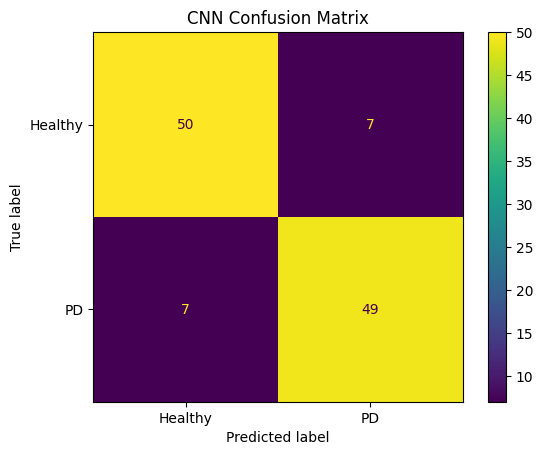

Accuracy:	0.8761
Sensitivity:	0.8750
Specificity:	0.8772

Full Report:
              precision    recall  f1-score   support

     Healthy       0.88      0.88      0.88        57
          PD       0.88      0.88      0.88        56

    accuracy                           0.88       113
   macro avg       0.88      0.88      0.88       113
weighted avg       0.88      0.88      0.88       113



In [15]:
import matplotlib.pyplot as plt

tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()

print(f"TP: {tp}\tPD detected")
print(f"TN: {tn}\tHealthy detected")
print(f"FP: {fp}\tHealthy missdiagnosed")
print(f"FN: {fn}\tPD missed")

disp = ConfusionMatrixDisplay.from_predictions(all_labels, all_preds, display_labels=['Healthy', 'PD'])
plt.title('CNN Confusion Matrix')
plt.show()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
accuracy    = (tp + tn) / (tp + tn + fp + fn)

print(f"Accuracy:\t{accuracy:.4f}")
print(f"Sensitivity:\t{sensitivity:.4f}") # (Recall)
print(f"Specificity:\t{specificity:.4f}")
print("\nFull Report:")
print(classification_report(all_labels, all_preds, target_names=['Healthy', 'PD']))

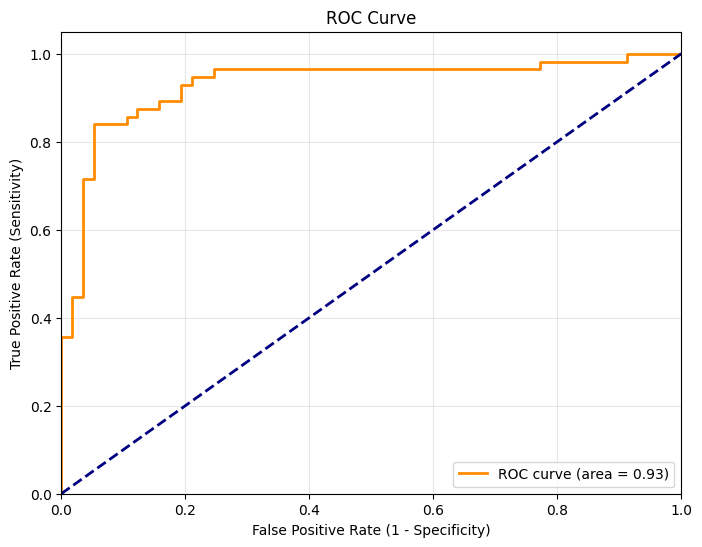

Total AUC: 0.9305


In [16]:
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:0.2f})')

# Plot the diagonal (random classifier baseline)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Total AUC: {roc_auc:.4f}")

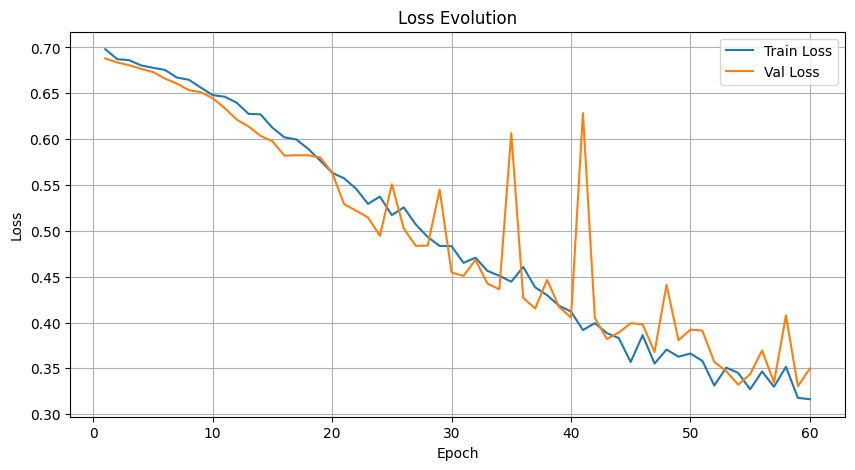

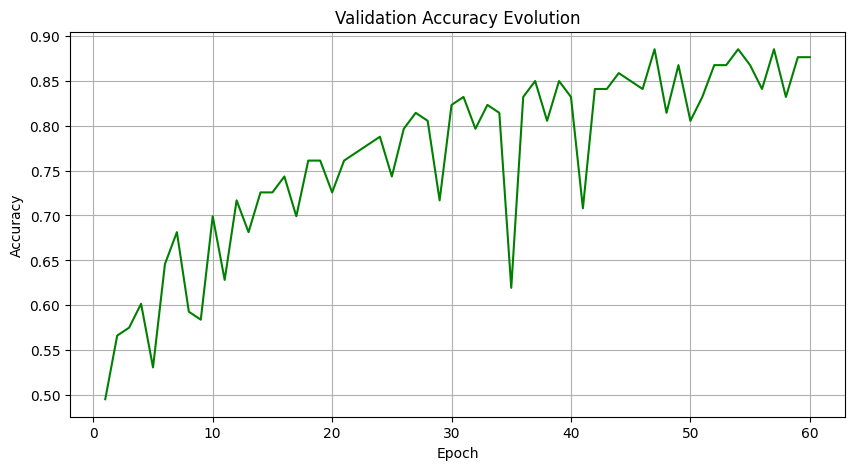

In [18]:
## visualise the code from the generated csv:
import pandas as pd
import matplotlib.pyplot as plt
#df = pd.read_csv('outputs/' + MODEL_NAME + '/training_log.csv')
df = pd.read_csv('outputs/' + CONFIG['model_name'] + '_20260419_235949/training_log.csv')


plt.figure(figsize=(10, 5))
plt.plot(df['epoch'], df['train_loss'], label='Train Loss')
plt.plot(df['epoch'], df['val_loss'], label='Val Loss')
plt.title('Loss Evolution')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.figure(figsize=(10, 5))
plt.plot(df['epoch'], df['val_acc'], label='Val Accuracy', color='green')
plt.title('Validation Accuracy Evolution')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()